# Forecasting electricity demand in Lithuania

This project uses only publicly available data: [electricity demand](https://data.gov.lt/datasets/2903/?resource_version=705), [meteorological observations](https://data.gov.lt/datasets/3872/) and [population in municipalities](https://www.registrucentras.lt/atviri-duomenys-ir-statistika/gyventoju-skaicius-pagal-apskritis).

#### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from pmdarima.arima.utils import ndiffs
from pmdarima.arima.utils import nsdiffs

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Dataset import

In [2]:
data = pd.read_csv('./data/vartojimas-203.csv',
                   engine='pyarrow',
                   parse_dates=['ltu', 'utc'])

#### Main dataset overview

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   id      27361 non-null  int64        
 1   value   27361 non-null  float64      
 2   ltu     27361 non-null  datetime64[s]
 3   utc     27361 non-null  datetime64[s]
dtypes: datetime64[s](2), float64(1), int64(1)
memory usage: 855.2 KB


Our dataset contains 3 useful columns: `value` (de facto national energy consumption in MW each hour), `ltu` (time in Lithuania) and `utc`.

In [4]:
data.head()

,id,value,ltu,utc
0,203,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00
1,203,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00
2,203,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00
3,203,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00
4,203,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00


Column `id` does not contain any useful information.

In [5]:
data = data.drop(columns=['id'])

In [6]:
data

,value,ltu,utc
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00
...,...,...,...
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00
27359,1533.344,2026-02-14 01:00:00,2026-02-13 23:00:00


In [7]:
data[data.value == 0]

,value,ltu,utc


No values are equal to 0.

In [8]:
data.value.isna().sum()

np.int64(0)

No values are equal are missing.

#### Time series overview

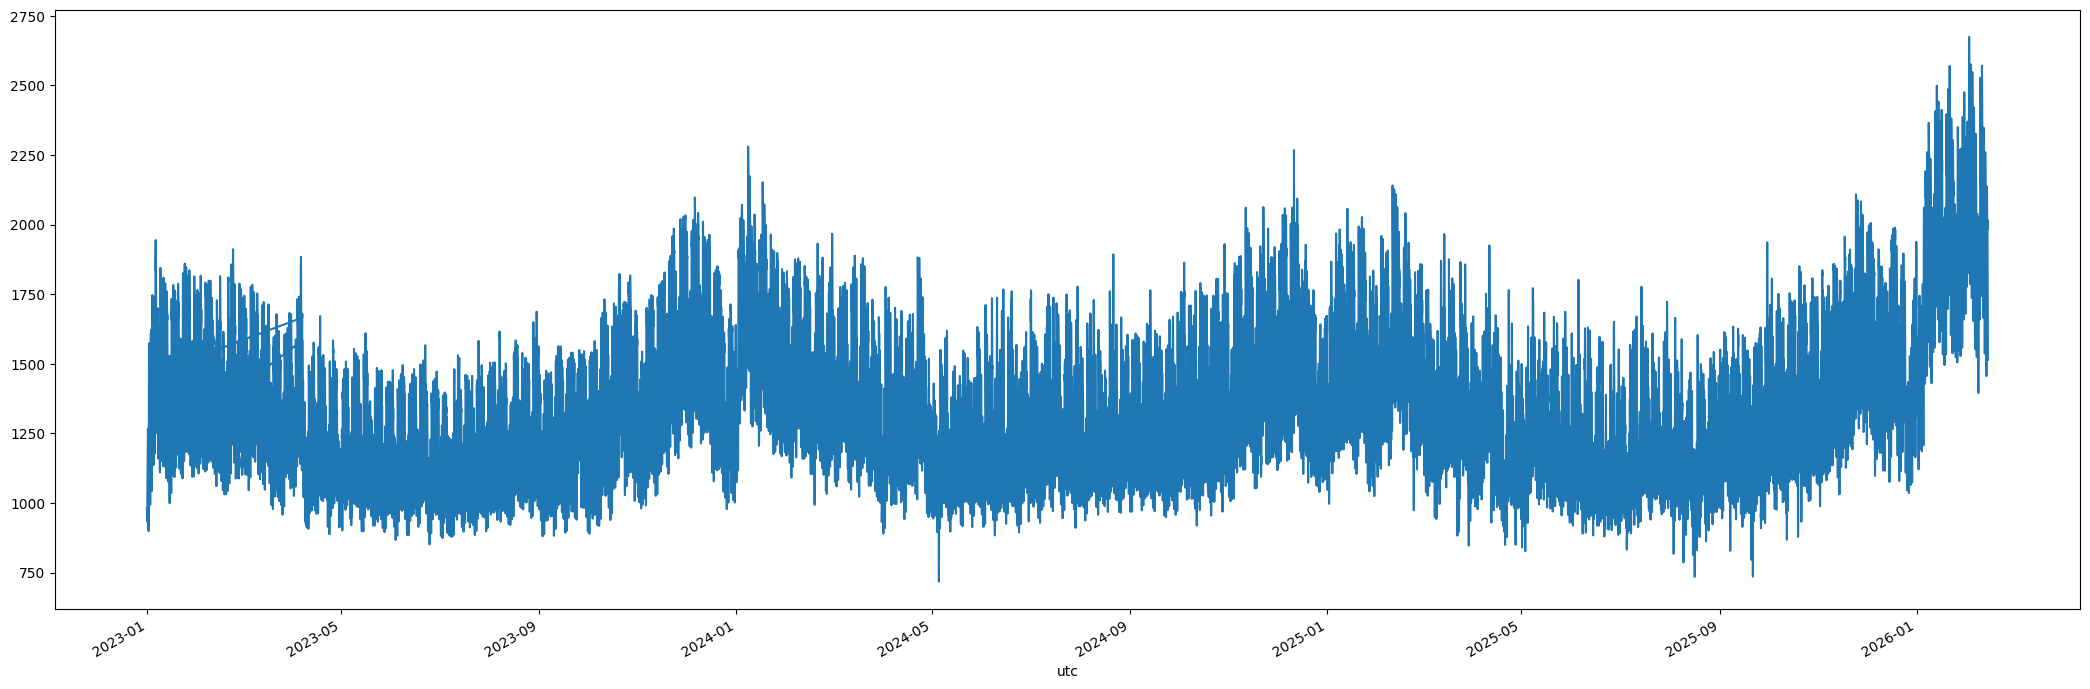

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

data.plot(x='utc',
          y='value',
          legend=False,
          ax=ax)

plt.tight_layout()
plt.show()

Let's extract time-based features from the timestamp.

In [10]:
data['date'] = data['utc'].dt.date
data['day_of_week'] = data['utc'].dt.day_of_week
data['month'] = data['utc'].dt.month
data['year'] = data['utc'].dt.year
data['hour'] = data['utc'].dt.hour
data['day_of_year'] = data['utc'].dt.day_of_year

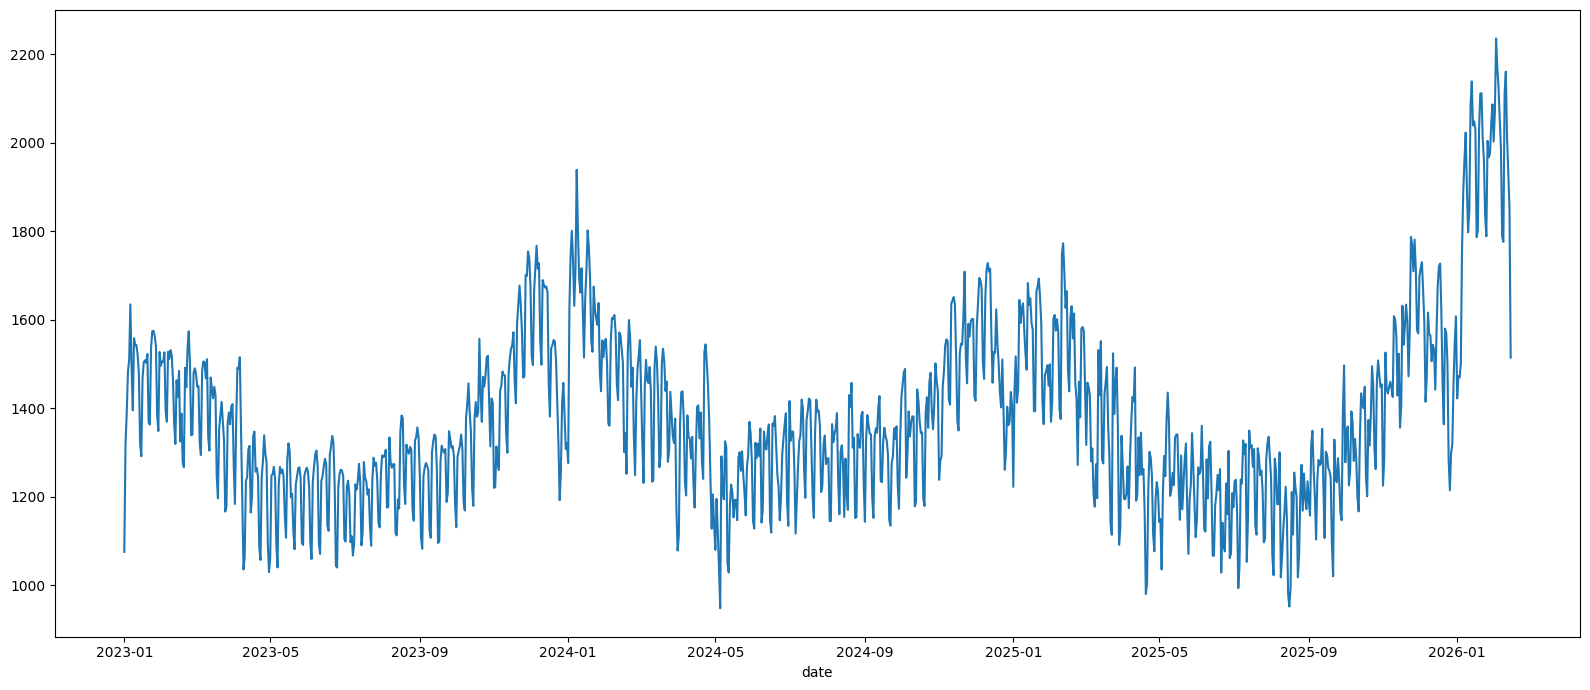

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

data.groupby('date')['value'].mean().plot(ax=ax)

plt.tight_layout()
plt.show()

We can clearly see a yearly and some sort of weekly seasonality from the chart.

We will want to predict electricity demand based of external variables. One such group of variables could be related to weather.

#### Weather data

In [12]:
weather = pd.read_csv('./data/Matavimas.csv',
                      engine='pyarrow')

In [13]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430012 entries, 0 to 2430011
Data columns (total 20 columns):
 #   Column               Dtype        
---  ------               -----        
 0   _type                object       
 1   _id                  object       
 2   _revision            object       
 3   _page.next           object       
 4   vda_prime_key        object       
 5   stoties_pavadinimas  object       
 6   stoties_kodas        object       
 7   ilguma               float64      
 8   platuma              float64      
 9   stebejimo_laikas     datetime64[s]
 10  oro_temp             float64      
 11  juntamoji_temp       float64      
 12  vejo_greitis         float64      
 13  vejo_gusis           float64      
 14  vejo_kryptis         float64      
 15  debesuotumas         float64      
 16  slegis_juros_lyg     float64      
 17  santyk_oro_dregme    float64      
 18  kritutliu_kiekis     float64      
 19  oro_salygos          object       
dtypes:

`oro_temp` (air temperature) column interests us the most. Readings are hourly.

Let's drop junk variables and filter a timeframe that matches the timeframe of electricity data.

In [14]:
weather = weather.drop(columns=['_type', '_id', '_revision', '_page.next', 'vda_prime_key'])

In [15]:
weather = weather[weather['stebejimo_laikas'].between(min(data['utc']), max(data['utc']))]

In [16]:
weather = weather.sort_values('stebejimo_laikas').reset_index(drop=True)

In [17]:
weather.head()

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
0,Utenos AMS,utenos-ams,25.589692,55.515321,2023-01-01,8.8,8.8,2.3,4.3,206.0,100.0,1005.8,96.0,0.0,nedidelis lietus
1,Raseinių AMS,raseiniu-ams,23.133073,55.394569,2023-01-01,10.4,10.4,4.9,9.4,231.0,100.0,1004.9,96.0,0.4,nedidelis lietus
2,Panevėžio AMS,panevezio-ams,24.417184,55.735154,2023-01-01,10.0,10.0,4.3,6.3,209.0,100.0,1004.5,98.0,0.0,lietus
3,Klaipėdos AMS,klaipedos-ams,21.091570,55.731350,2023-01-01,7.7,7.7,4.3,9.7,226.0,100.0,1004.0,99.0,2.6,nedidelis lietus
4,Šiaulių AMS,siauliu-ams,23.331111,55.942222,2023-01-01,10.2,10.2,3.2,6.6,227.0,100.0,1003.4,94.0,0.4,nedidelis lietus


In [18]:
weather.tail()

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
895896,Jurbarko AMS,jurbarko-ams,22.773518,55.094064,2026-02-12 23:00:00,-2.8,NaN,NaN,NaN,NaN,NaN,NaN,96.0,0.0,None
895897,Ukmergės AMS,ukmerges-ams,24.760335,55.264145,2026-02-12 23:00:00,-0.2,-3.6,2.8,3.9,56.0,100.0,988.9,97.0,0.0,debesuota
895898,Ventės AMS,ventes-ams,21.189682,55.340853,2026-02-12 23:00:00,-3.1,-8.7,4.9,8.3,73.0,NaN,NaN,96.0,1.0,None
895899,Kazlų Rūdos AMS,kazlu-rudos-ams,23.514815,54.699852,2026-02-12 23:00:00,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,98.0,0.0,None
895900,Klaipėdos AMS,klaipedos-ams,21.091570,55.731350,2026-02-12 23:00:00,-4.0,-9.3,4.1,8.5,80.0,100.0,987.8,99.0,1.1,smarkus sniegas


The dataset seems cohesive.

In [19]:
ams_to_city = {
  'Klaipėdos AMS': 'Klaipėda',
  'Nidos AMS': 'Neringa',
  'Raseinių AMS': 'Raseiniai',
  'Panevėžio AMS': 'Panevėžys',
  'Kauno AMS': 'Kaunas',
  'Varėnos AMS': 'Varėna',
  'Šiaulių AMS': 'Šiauliai',
  'Laukuvos AMS': 'Šilalė',
  'Dūkšto AMS': 'Ignalina',
  'Dotnuvos AMS': 'Kėdainiai',
  'Telšių AMS': 'Telšiai',
  'Šilutės AMS': 'Šilutė',
  'Utenos AMS': 'Utena',
  'Biržų AMS': 'Biržai',
  'Kybartų AMS': 'Vilkaviškis',
  'Lazdijų AMS': 'Lazdijai',
  'Vilniaus AMS': 'Vilnius',
  'Ukmergės AMS': 'Ukmergė',
  'Molėtų AMS': 'Molėtai',
  'Birštono AMS': 'Birštonas',
  'Vėžaičių AMS': 'Vėžaičiai',
  'Kretingos AMS': 'Kretinga',
  'Prienų AMS': 'Prienai',
  'Zarasų AMS': 'Zarasai',
  'Alytaus AMS': 'Alytus',
  'Kalvarijos AMS': 'Kalvarija',
  'Trakų AMS': 'Trakai',
  'Šeduvos AMS': 'Radviliškis',
  'Joniškio AMS': 'Joniškis',
  'Pakruojo AMS': 'Pakruojis',
  'Mažeikių AMS': 'Mažeikiai',
  'Šakių AMS': 'Šakiai',
  'Kelmės AMS': 'Kelmė',
  'Elektrėnų AMS': 'Elektrėnai',
  'Šalčininkų AMS': 'Šalčininkai',
  'Pagėgių AMS': 'Pagėgiai',
  'Druskininkų AMS': 'Druskininkai',
  'Rietavo AMS': 'Rietavas',
  'Skuodo AMS': 'Skuodas',
  'Švenčionių AMS': 'Švenčionys',
  'Rokiškio AMS': 'Rokiškis',
  'Anykščių AMS': 'Anykščiai',
  'Kaišiadorių AMS': 'Kaišiadorys',
  'Kupiškio AMS': 'Kupiškis',
  'Ventės AMS': 'Šilutė',
  'Jurbarko AMS': 'Jurbarkas',
  'Akmenės AMS': 'Akmenė',
  'Tauragės AMS': 'Tauragė',
  'Kazlų Rūdos AMS': 'Kazlų Rūda',
  'Plungės AMS': 'Plungė',
  'Marijampolės AMS': 'Marijampolė',
  'Jonavos AMS': 'Jonava',
  'Vėžaičių AMS': 'Klaipėda'
}

In [20]:
weather['city'] = weather['stoties_pavadinimas'].map(ams_to_city)

Since temperature in different cities will vary, we will need to create a weighted average based on the number of consumers which we can aproximate using population data.

#### Population data

In [21]:
pop = pd.read_excel('./data/gyventojai-26-01.xlsx', header=1, index_col='Eil. nr.')

In [22]:
pop.columns

Index(['Savivaldybės pavadinimas', 'Bendras gyventojų skaičius', 'Vyrai',
       'Moterys', 'nuo 0 iki 6', 'nuo 7 iki 17', 'nuo 18 iki 29',
       'nuo 30 iki 39', 'nuo 40 iki 49', 'nuo 50 iki 59', 'nuo 60 iki 64',
       'nuo 65 iki 74', 'nuo 75 iki 84', 'nuo 85'],
      dtype='object')

In [23]:
muni_to_city = {
  'Akmenės r. sav.': 'Akmenė',
  'Alytaus m. sav.': 'Alytus',
  'Alytaus r. sav.': 'Alytus',
  'Anykščių r. sav.': 'Anykščiai',
  'Birštono sav.': 'Birštonas',
  'Biržų r. sav.': 'Biržai',
  'Druskininkų sav.': 'Druskininkai',
  'Elektrėnų sav.': 'Elektrėnai',
  'Ignalinos r. sav.': 'Ignalina',
  'Jonavos r. sav.': 'Jonava',
  'Joniškio r. sav.': 'Joniškis',
  'Jurbarko r. sav.': 'Jurbarkas',
  'Kaišiadorių r. sav.': 'Kaišiadorys',
  'Kalvarijos sav.': 'Kalvarija',
  'Kauno m. sav.': 'Kaunas',
  'Kauno r. sav.': 'Kaunas',
  'Kazlų Rūdos sav.': 'Kazlų Rūda',
  'Kelmės r. sav.': 'Kelmė',
  'Klaipėdos m. sav.': 'Klaipėda',
  'Klaipėdos r. sav.': 'Klaipėda',
  'Kretingos r. sav.': 'Kretinga',
  'Kupiškio r. sav.': 'Kupiškis',
  'Kėdainių r. sav.': 'Kėdainiai',
  'Lazdijų r. sav.': 'Lazdijai',
  'Marijampolės sav.': 'Marijampolė',
  'Mažeikių r. sav.': 'Mažeikiai',
  'Molėtų r. sav.': 'Molėtai',
  'Neringos sav.': 'Neringa',
  'Pagėgių sav.': 'Pagėgiai',
  'Pakruojo r. sav.': 'Pakruojis',
  'Palangos m. sav.': 'Palanga',
  'Panevėžio m. sav.': 'Panevėžys',
  'Panevėžio r. sav.': 'Panevėžys',
  'Pasvalio r. sav.': 'Pasvalys',
  'Plungės r. sav.': 'Plungė',
  'Prienų r. sav.': 'Prienai',
  'Radviliškio r. sav.': 'Radviliškis',
  'Raseinių r. sav.': 'Raseiniai',
  'Rietavo sav.': 'Rietavas',
  'Rokiškio r. sav.': 'Rokiškis',
  'Skuodo r. sav.': 'Skuodas',
  'Tauragės r. sav.': 'Tauragė',
  'Telšių r. sav.': 'Telšiai',
  'Trakų r. sav.': 'Trakai',
  'Ukmergės r. sav.': 'Ukmergė',
  'Utenos r. sav.': 'Utena',
  'Varėnos r. sav.': 'Varėna',
  'Vilkaviškio r. sav.': 'Vilkaviškis',
  'Vilniaus m. sav.': 'Vilnius',
  'Vilniaus r. sav.': 'Vilnius',
  'Visagino sav.': 'Visaginas',
  'Zarasų r. sav.': 'Zarasai',
  'Šakių r. sav.': 'Šakiai',
  'Šalčininkų r. sav.': 'Šalčininkai',
  'Šiaulių m. sav.': 'Šiauliai',
  'Šiaulių r. sav.': 'Šiauliai',
  'Šilalės r. sav.': 'Šilalė',
  'Šilutės r. sav.': 'Šilutė',
  'Širvintų r. sav.': 'Širvintos',
  'Švenčionių r. sav.': 'Švenčionys'
}

In [24]:
pop['city'] = pop['Savivaldybės pavadinimas'].map(muni_to_city)

In [25]:
pop = pop.groupby('city')['Bendras gyventojų skaičius'].sum()

In [26]:
weather = weather.merge(pop, on='city', how='left').rename(columns={'Bendras gyventojų skaičius':'gyventoju_skaicius'})

In [27]:
weather

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos,city,gyventoju_skaicius
0,Utenos AMS,utenos-ams,25.589692,55.515321,2023-01-01 00:00:00,8.8,8.8,2.3,4.3,206.0,100.0,1005.8,96.0,0.0,nedidelis lietus,Utena,39481
1,Raseinių AMS,raseiniu-ams,23.133073,55.394569,2023-01-01 00:00:00,10.4,10.4,4.9,9.4,231.0,100.0,1004.9,96.0,0.4,nedidelis lietus,Raseiniai,30382
2,Panevėžio AMS,panevezio-ams,24.417184,55.735154,2023-01-01 00:00:00,10.0,10.0,4.3,6.3,209.0,100.0,1004.5,98.0,0.0,lietus,Panevėžys,124558
3,Klaipėdos AMS,klaipedos-ams,21.091570,55.731350,2023-01-01 00:00:00,7.7,7.7,4.3,9.7,226.0,100.0,1004.0,99.0,2.6,nedidelis lietus,Klaipėda,247654
4,Šiaulių AMS,siauliu-ams,23.331111,55.942222,2023-01-01 00:00:00,10.2,10.2,3.2,6.6,227.0,100.0,1003.4,94.0,0.4,nedidelis lietus,Šiauliai,164217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895896,Jurbarko AMS,jurbarko-ams,22.773518,55.094064,2026-02-12 23:00:00,-2.8,NaN,NaN,NaN,NaN,NaN,NaN,96.0,0.0,None,Jurbarkas,26754
895897,Ukmergės AMS,ukmerges-ams,24.760335,55.264145,2026-02-12 23:00:00,-0.2,-3.6,2.8,3.9,56.0,100.0,988.9,97.0,0.0,debesuota,Ukmergė,35810
895898,Ventės AMS,ventes-ams,21.189682,55.340853,2026-02-12 23:00:00,-3.1,-8.7,4.9,8.3,73.0,NaN,NaN,96.0,1.0,None,Šilutė,40518
895899,Kazlų Rūdos AMS,kazlu-rudos-ams,23.514815,54.699852,2026-02-12 23:00:00,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,98.0,0.0,None,Kazlų Rūda,11222


Now, with the joined dataset, we can calculate the weighted average.

In [28]:
weighted_temp = (
    (weather['oro_temp'] * weather['gyventoju_skaicius'])
    .groupby(weather['stebejimo_laikas'])
    .sum()
    / weather.groupby('stebejimo_laikas')['gyventoju_skaicius'].sum()
)

In [29]:
weighted_temp.isna().sum()

np.int64(0)

The are no missing values, but that is due to some time indexed being missing.

In [30]:
weighted_temp

stebejimo_laikas
2023-01-01 00:00:00    8.820090
2023-01-01 01:00:00    9.240350
2023-01-01 02:00:00    9.591937
2023-01-01 03:00:00    9.468869
2023-01-01 04:00:00    9.398759
                         ...   
2026-02-12 19:00:00   -1.981541
2026-02-12 20:00:00   -2.106984
2026-02-12 21:00:00   -2.926862
2026-02-12 22:00:00   -2.866254
2026-02-12 23:00:00   -1.917768
Length: 26237, dtype: float64

In [31]:
full_time = pd.Series(np.arange(min(data['utc']), max(data['utc']), dtype='datetime64[h]'))

In [32]:
full_time_df = pd.DataFrame(np.arange(min(data['utc']), max(data['utc']), dtype='datetime64[h]'), columns=['time'])

In [33]:
stations_series = pd.DataFrame(weather.stoties_kodas.unique(), columns=['station'])

In [34]:
full_time_station = full_time_df.merge(stations_series, how='cross')

In [35]:
weather.merge(full_time_station,
              left_on=['stebejimo_laikas', 'stoties_kodas'],
              right_on=['time', 'station'],
              how='right',
              indicator=True).query('_merge == "right_only"').drop(columns=['_merge']).shape

(526824, 19)

There are a total of 526824 missing temperature values (when looking at stations individually). Filling missing values would require at least 3 hours of API requests since METEO API has a 120 RPM limit. We will interpolate (predict) values instead.

In [36]:
full_temp = weighted_temp.reindex(full_time).rename('weighted_temp').reset_index().rename(columns={'index': 'time'})

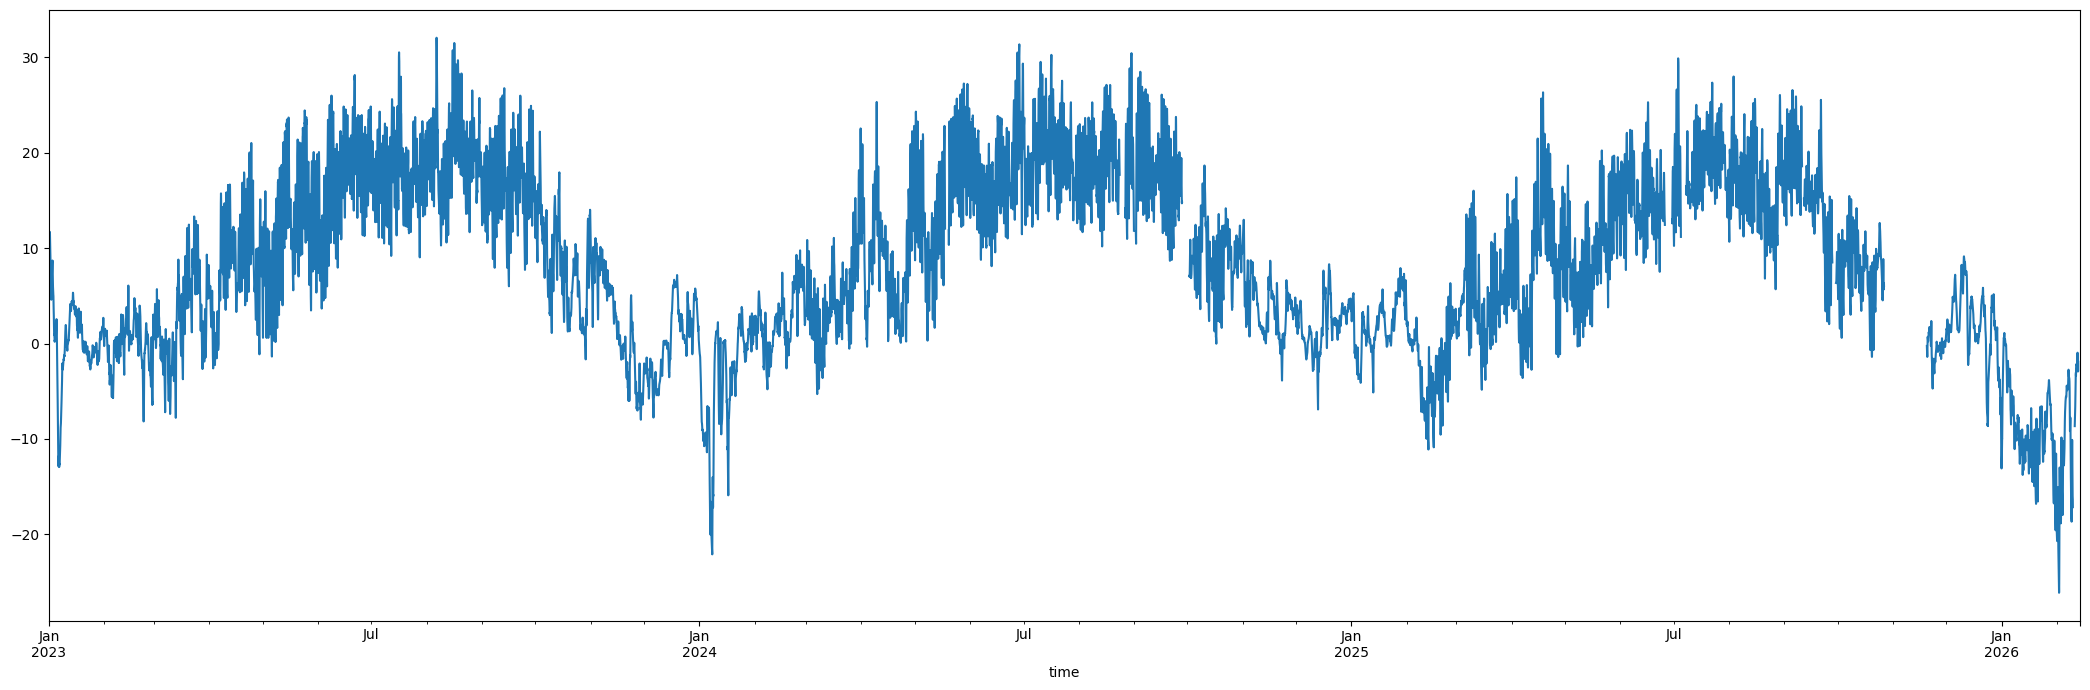

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

full_temp.plot(x='time', y='weighted_temp', ax=ax, legend=False)

plt.tight_layout()
plt.show()

There is a large segment missing from the November-December period in 2025. Other missing values are not as obvious.

In [38]:
weighted_temp_df = pd.DataFrame(weighted_temp.reset_index(name='temp'))

We can extract time-based variables which will be later provided to the model so that it could learn the time-temperature relationship.

In [39]:
weighted_temp_df['day'] = weighted_temp_df['stebejimo_laikas'].dt.day

In [40]:
weighted_temp_df['month'] = weighted_temp_df['stebejimo_laikas'].dt.month

In [41]:
weighted_temp_df['year'] = weighted_temp_df['stebejimo_laikas'].dt.year

In [42]:
weighted_temp_df['hour'] = weighted_temp_df['stebejimo_laikas'].dt.hour

In [43]:
weighted_temp_df['day_of_year'] = weighted_temp_df['stebejimo_laikas'].dt.day_of_year

In [44]:
weighted_temp_df

,stebejimo_laikas,temp,day,month,year,hour,day_of_year
0,2023-01-01 00:00:00,8.820090,1,1,2023,0,1
1,2023-01-01 01:00:00,9.240350,1,1,2023,1,1
2,2023-01-01 02:00:00,9.591937,1,1,2023,2,1
3,2023-01-01 03:00:00,9.468869,1,1,2023,3,1
4,2023-01-01 04:00:00,9.398759,1,1,2023,4,1
...,...,...,...,...,...,...,...
26232,2026-02-12 19:00:00,-1.981541,12,2,2026,19,43
26233,2026-02-12 20:00:00,-2.106984,12,2,2026,20,43
26234,2026-02-12 21:00:00,-2.926862,12,2,2026,21,43
26235,2026-02-12 22:00:00,-2.866254,12,2,2026,22,43


One of the models that we can use when we have missing data is Random Forest. For now, we will use the full dataset to train the model.

In [45]:
from sklearn.ensemble import RandomForestRegressor

temp_model = RandomForestRegressor()

X = weighted_temp_df[['hour', 'day', 'month', 'year', 'day_of_year']]

Y = weighted_temp_df[['temp']]

temp_model.fit(X, Y)

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [46]:
weighted_temp_df['predicted'] = temp_model.predict(X)

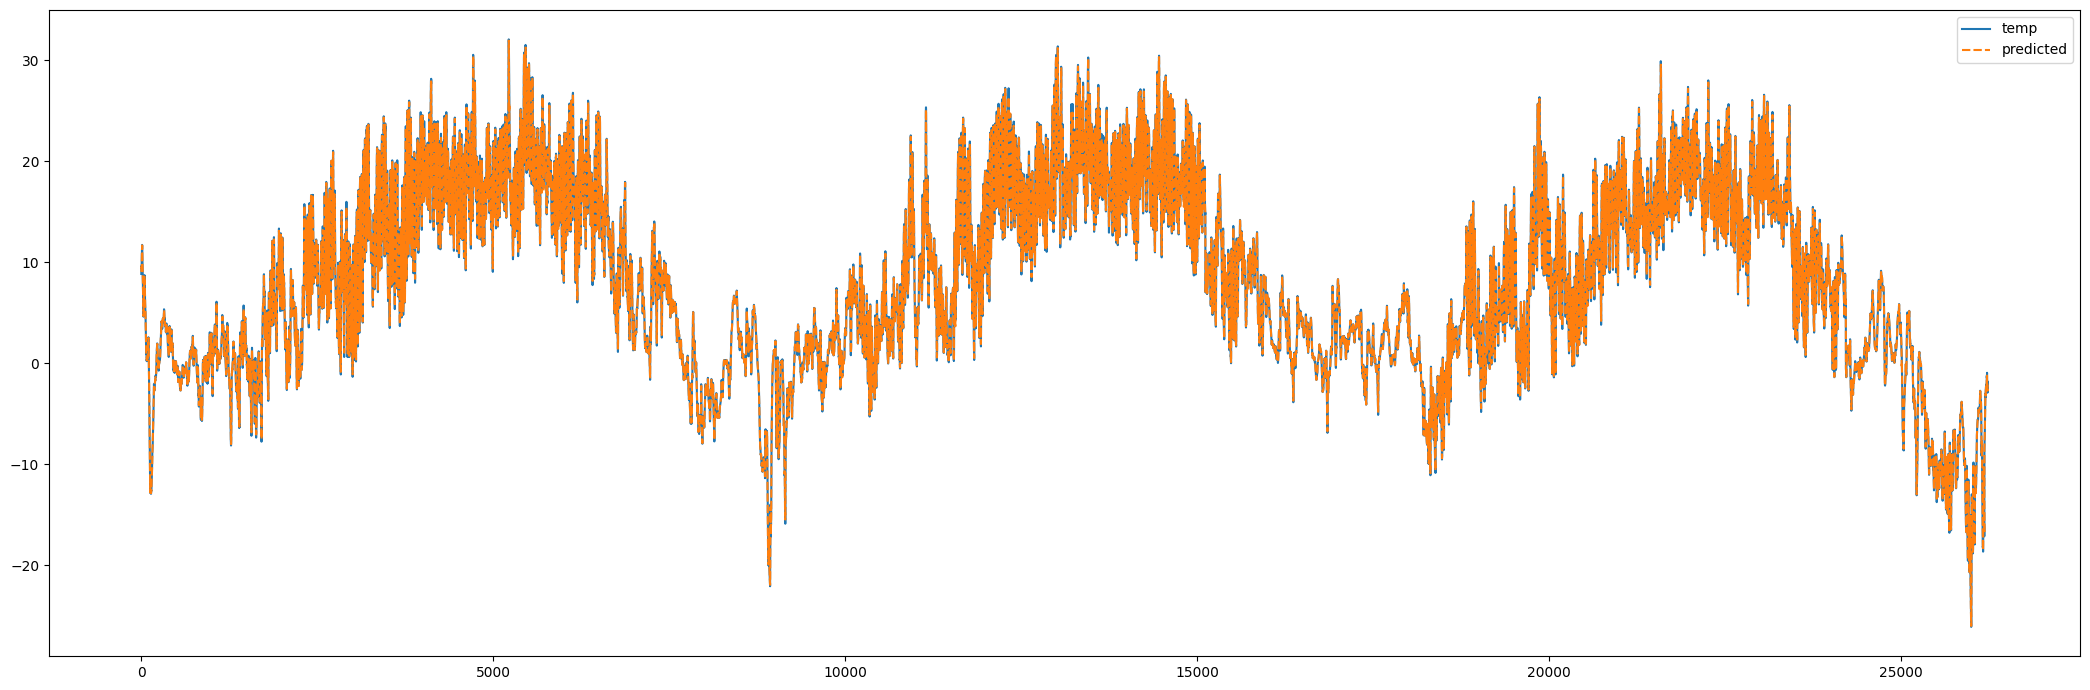

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(weighted_temp_df[['temp', 'predicted']], ax=ax)

plt.tight_layout()
plt.show()

The ground fact and predicted values are overlaping as we would like.

In [48]:
weighted_temp_df['diff'] = weighted_temp_df['temp'] - weighted_temp_df['predicted']

In [49]:
full_temp['day'] = full_temp['time'].dt.day
full_temp['month'] = full_temp['time'].dt.month
full_temp['year'] = full_temp['time'].dt.year
full_temp['hour'] = full_temp['time'].dt.hour
full_temp['day_of_year'] = full_temp['time'].dt.day_of_year

In [50]:
mask = full_temp.weighted_temp.isna()

full_temp.loc[mask, 'predicted'] = temp_model.predict(
    full_temp.loc[mask, ['hour', 'day', 'month', 'year', 'day_of_year']]
)

In [51]:
full_temp

,time,weighted_temp,day,month,year,hour,day_of_year,predicted
0,2023-01-01 00:00:00,8.820090,1,1,2023,0,1,NaN
1,2023-01-01 01:00:00,9.240350,1,1,2023,1,1,NaN
2,2023-01-01 02:00:00,9.591937,1,1,2023,2,1,NaN
3,2023-01-01 03:00:00,9.468869,1,1,2023,3,1,NaN
4,2023-01-01 04:00:00,9.398759,1,1,2023,4,1,NaN
...,...,...,...,...,...,...,...,...
27355,2026-02-13 19:00:00,NaN,13,2,2026,19,44,-2.008577
27356,2026-02-13 20:00:00,NaN,13,2,2026,20,44,-2.150301
27357,2026-02-13 21:00:00,NaN,13,2,2026,21,44,-2.680464
27358,2026-02-13 22:00:00,NaN,13,2,2026,22,44,-2.726520


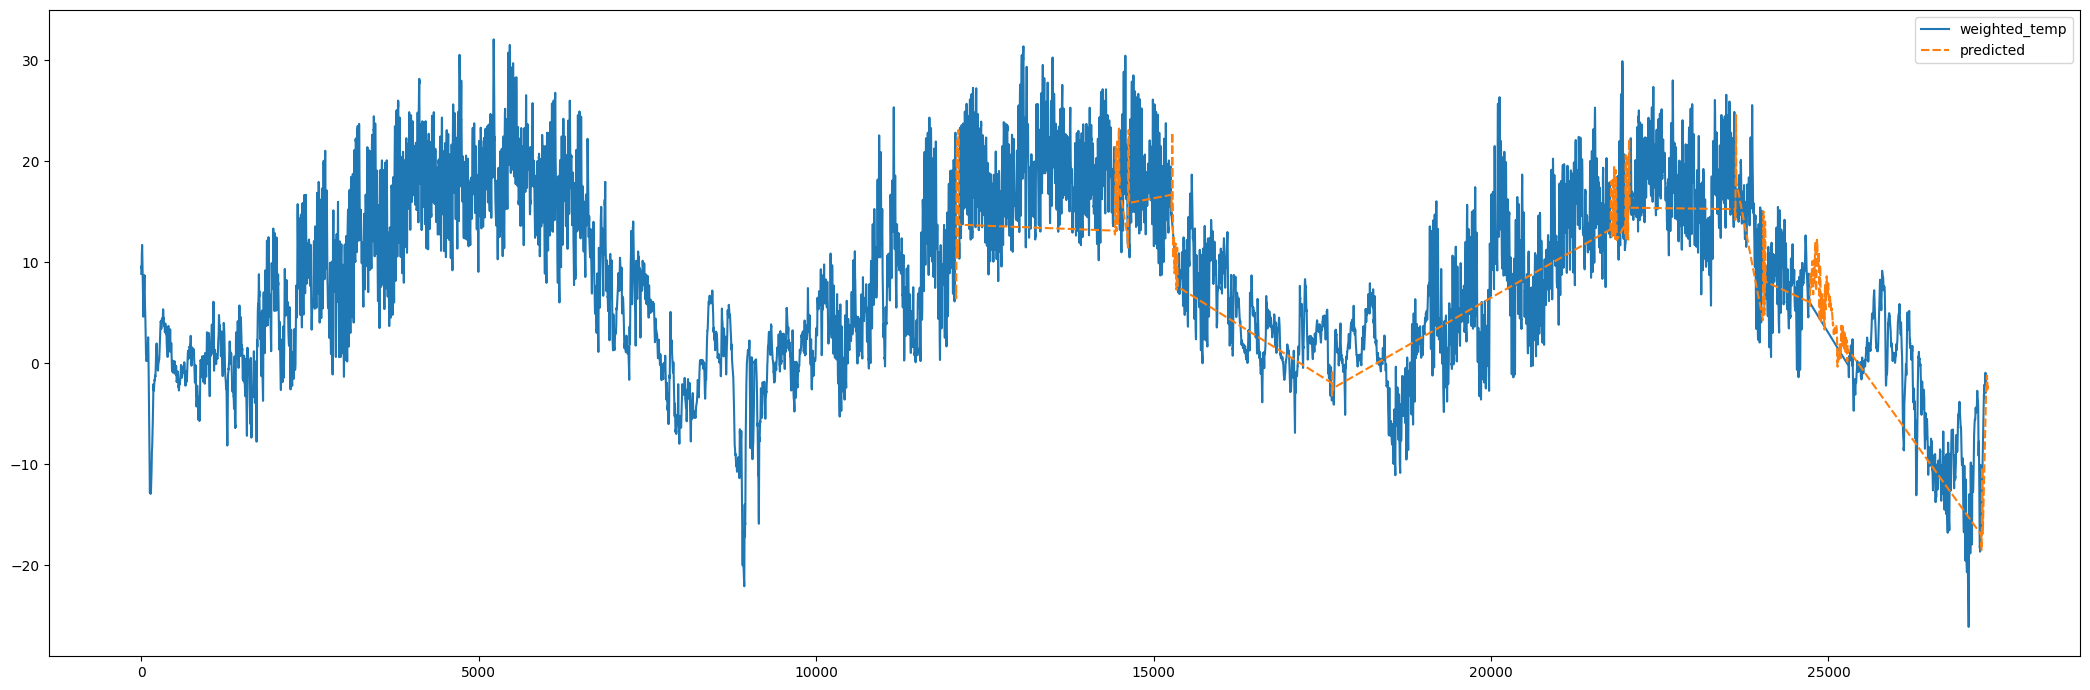

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(full_temp[['time', 'weighted_temp', 'predicted']])

plt.tight_layout()
plt.show()

All missing values that were not visible before are now marked in orange.

In [53]:
full_temp['final'] = full_temp['weighted_temp'].fillna(0) + full_temp['predicted'].fillna(0)

In [54]:
data = pd.merge(data, full_temp[['time', 'final']], left_on='utc', right_on='time').drop(columns='time').rename(columns={'final':'temp'})

In [55]:
data

,value,ltu,utc,date,day_of_week,month,year,hour,day_of_year,temp
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00,2023-01-01,6,1,2023,0,1,8.820090
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00,2023-01-01,6,1,2023,1,1,9.240350
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00,2023-01-01,6,1,2023,2,1,9.591937
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00,2023-01-01,6,1,2023,3,1,9.468869
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00,2023-01-01,6,1,2023,4,1,9.398759
...,...,...,...,...,...,...,...,...,...,...
27355,1847.633,2026-02-13 21:00:00,2026-02-13 19:00:00,2026-02-13,4,2,2026,19,44,-2.008577
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00,2026-02-13,4,2,2026,20,44,-2.150301
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00,2026-02-13,4,2,2026,21,44,-2.680464
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00,2026-02-13,4,2,2026,22,44,-2.726520


#### Time series decomposition

To predict time series using statistical methods such as SARIMAX, we must have a time series without any unit roots. All tests are calculated using $\alpha = 0.05.$

##### Stationarity

In [56]:
ndiffs(data['value'], test='adf')

0

In [57]:
ndiffs(data['value'], test='kpss')

1

In [58]:
ndiffs(data['value'], test='pp')

0

ADF and Philips Perron tests indicate that there is no unit root present. Integration of the time series will not be needed.

In [59]:
nsdiffs(data['value'],
        test='ocsb',
        m=8760,
        max_D=12)

0

Osborn, Chui, Smith, and Birchenhall test shows that seasonal differencing is also not necessary.

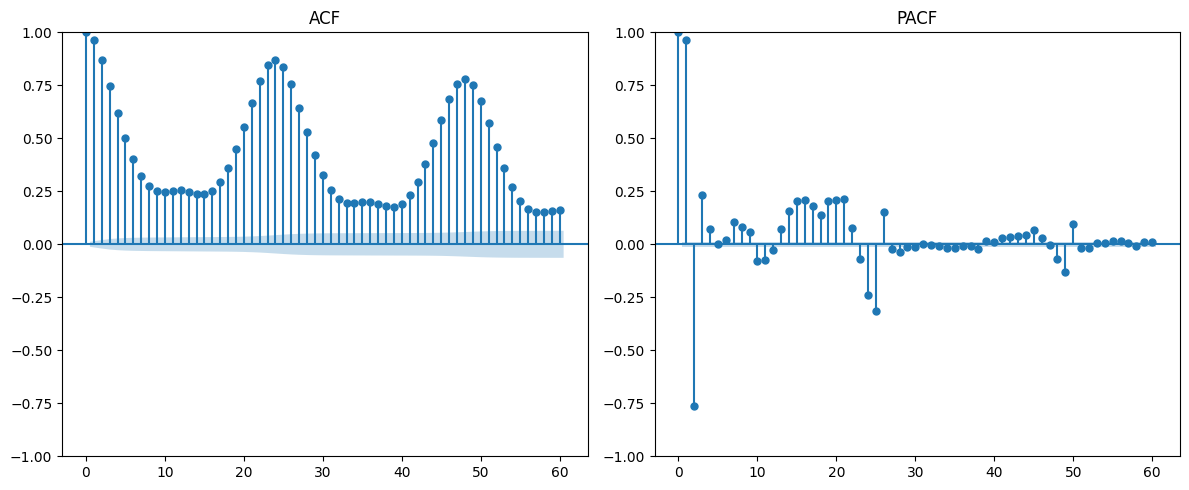

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(data["value"],
         lags=60,
         ax=axs[0])
axs[0].set_title("ACF")

plot_pacf(data["value"],
          lags=60,
          ax=axs[1])
axs[1].set_title('PACF')

plt.tight_layout()
plt.show()

The ACF chart is showning strong seasonality around every 24 hours, indicating that energy demand depends on the time of day. The PACF shows that energy demand is dependant on demand during the last hour.

In [61]:
print(acorr_ljungbox(data["value"], period=24)['lb_pvalue'].max())
print(acorr_ljungbox(data["value"], period=168)['lb_pvalue'].max())
print(acorr_ljungbox(data["value"], period=8760)['lb_pvalue'].max())

0.0
0.0
0.0


Since the p-value $ < 0.05$, we must reject the null hypothesis. The time series values are correlated.

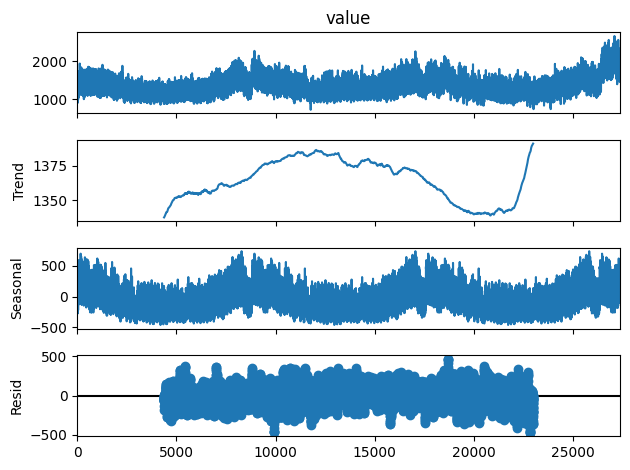

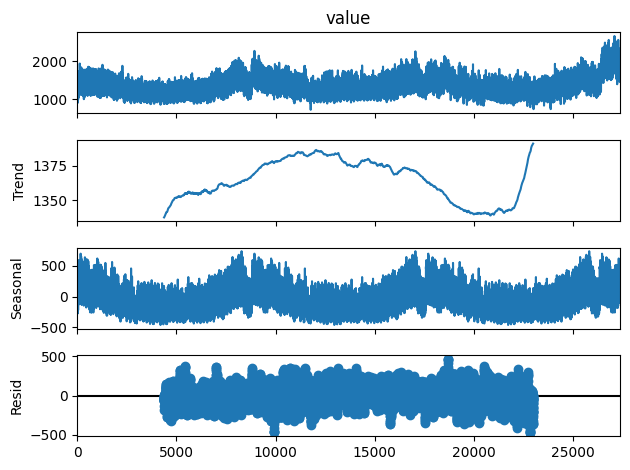

In [62]:
ts = seasonal_decompose(data['value'],
                        model='additive',
                        period=8760)

ts.plot()

After decomposing the time series using moving averages, a few things become clearer. We see that there is some sort of trend of demand growth over the most recent period (winter of 2026) and an increase in demand post-COVID. The seasonal part of the time series is also strong, indicating that seasons play a role in energy demand. Large residuals also show that not all valuable information is extracted with this decomposition method.

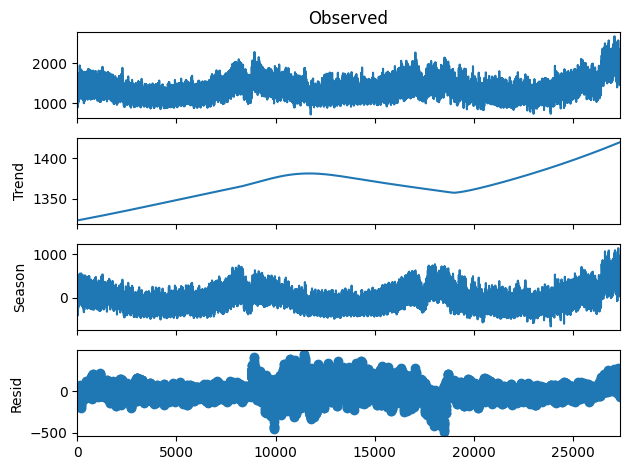

In [63]:
stl = STL(data[['value']], period=8760)
result = stl.fit()

result.plot()
plt.show()

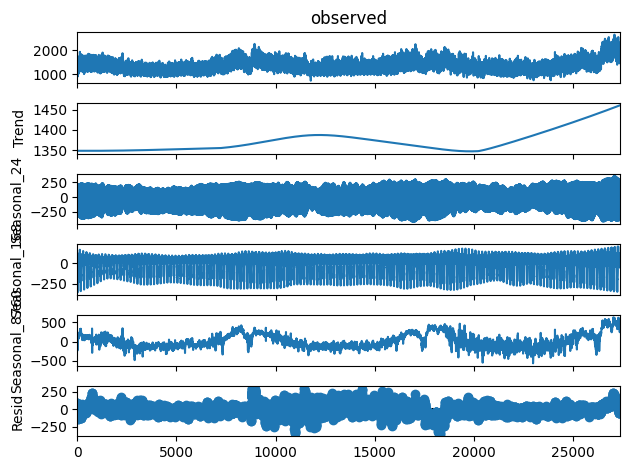

In [64]:
mstl = MSTL(data['value'], periods=[24, 168, 8760])
result = mstl.fit()

result.plot()
plt.show()

<Axes: >

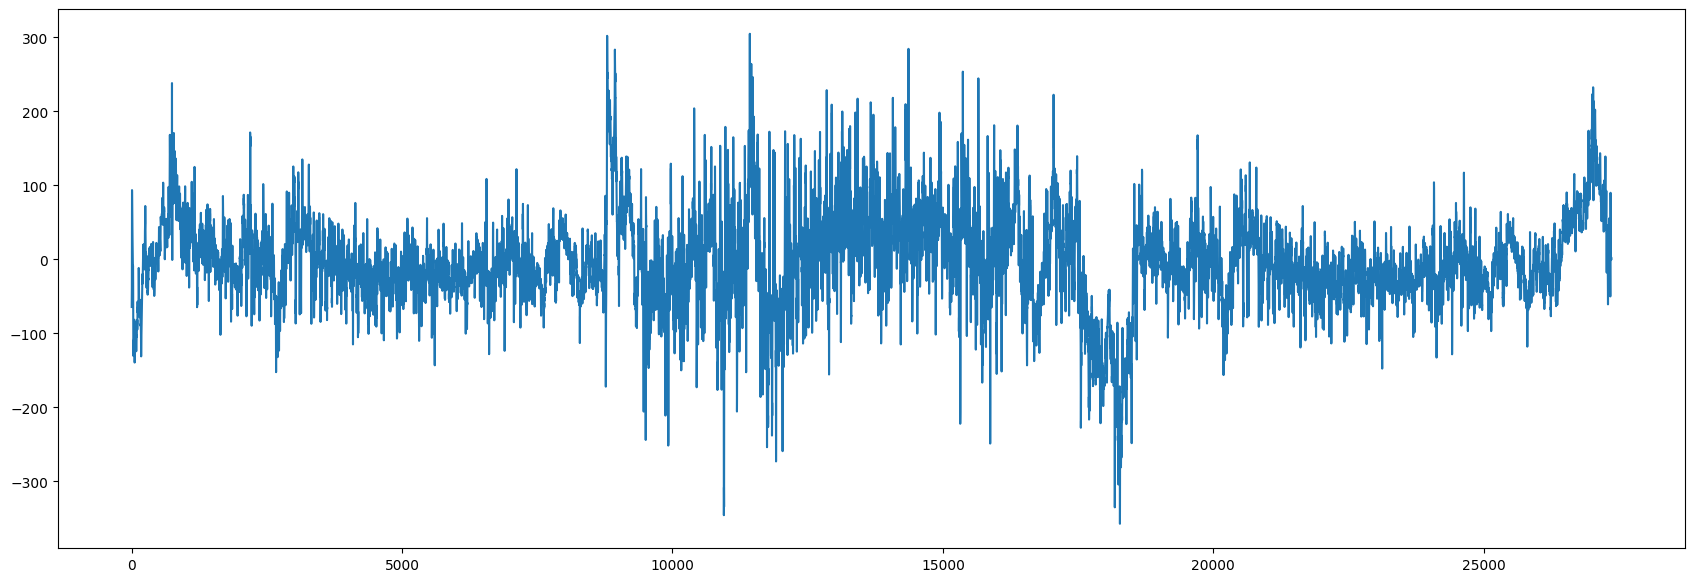

In [65]:
result.resid.plot(figsize=(21, 7))

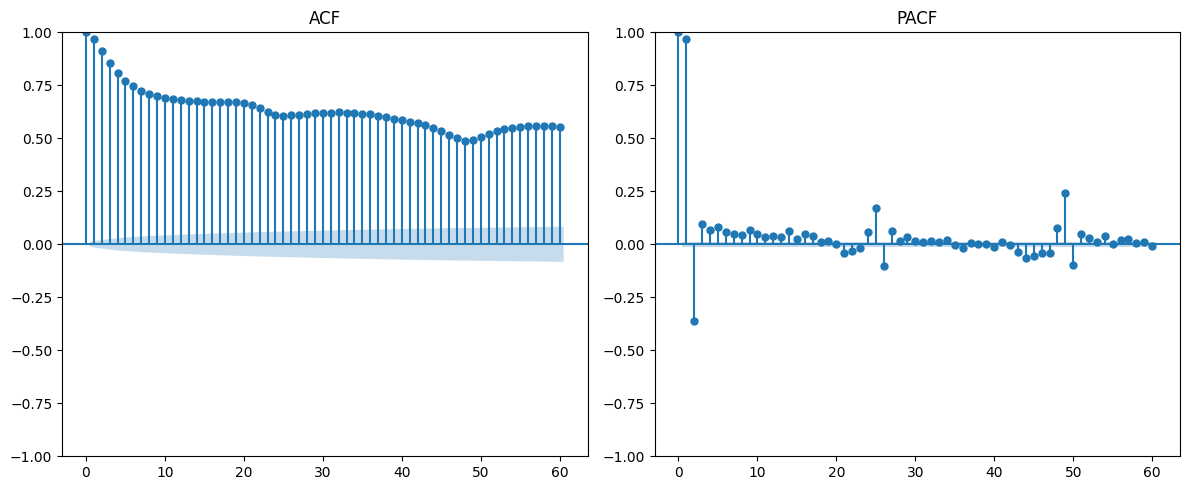

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(result.resid,
         lags=60,
         ax=axs[0])
axs[0].set_title("ACF")

plot_pacf(result.resid,
          lags=60,
          ax=axs[1])
axs[1].set_title('PACF')

plt.tight_layout()
plt.show()

In [67]:
print(acorr_ljungbox(result.resid, period=24)['lb_pvalue'].max())
print(acorr_ljungbox(result.resid, period=168)['lb_pvalue'].max())
print(acorr_ljungbox(result.resid, period=8760)['lb_pvalue'].max())

0.0
0.0
0.0


Even after decomposing the time series residuals still carry some information. The ACF function no longer shows clear daily seasonality. This might indicate that exogenous variables could play a role in predicting energy demand. 

In [68]:
data

,value,ltu,utc,date,day_of_week,month,year,hour,day_of_year,temp
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00,2023-01-01,6,1,2023,0,1,8.820090
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00,2023-01-01,6,1,2023,1,1,9.240350
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00,2023-01-01,6,1,2023,2,1,9.591937
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00,2023-01-01,6,1,2023,3,1,9.468869
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00,2023-01-01,6,1,2023,4,1,9.398759
...,...,...,...,...,...,...,...,...,...,...
27355,1847.633,2026-02-13 21:00:00,2026-02-13 19:00:00,2026-02-13,4,2,2026,19,44,-2.008577
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00,2026-02-13,4,2,2026,20,44,-2.150301
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00,2026-02-13,4,2,2026,21,44,-2.680464
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00,2026-02-13,4,2,2026,22,44,-2.726520


In [69]:
data['unique_id'] = 'Lithuania'

sf = StatsForecast(
    models=[AutoARIMA(d=0,
                      D=0,
                      season_length=168,
                      approximation=True)],
    freq='h',
    n_jobs=-1
)

sf.fit(data[['unique_id', 'utc', 'value', 'day_of_week', 'month', 'year', 'hour', 'day_of_year', 'temp']], 
       id_col='unique_id', 
       time_col='utc', 
       target_col='value')

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 1]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositor

StatsForecast(models=[AutoARIMA])

In [70]:
arima_string(sf.fitted_[0,0].model_)

'Regression with ARIMA(5,0,0) errors'

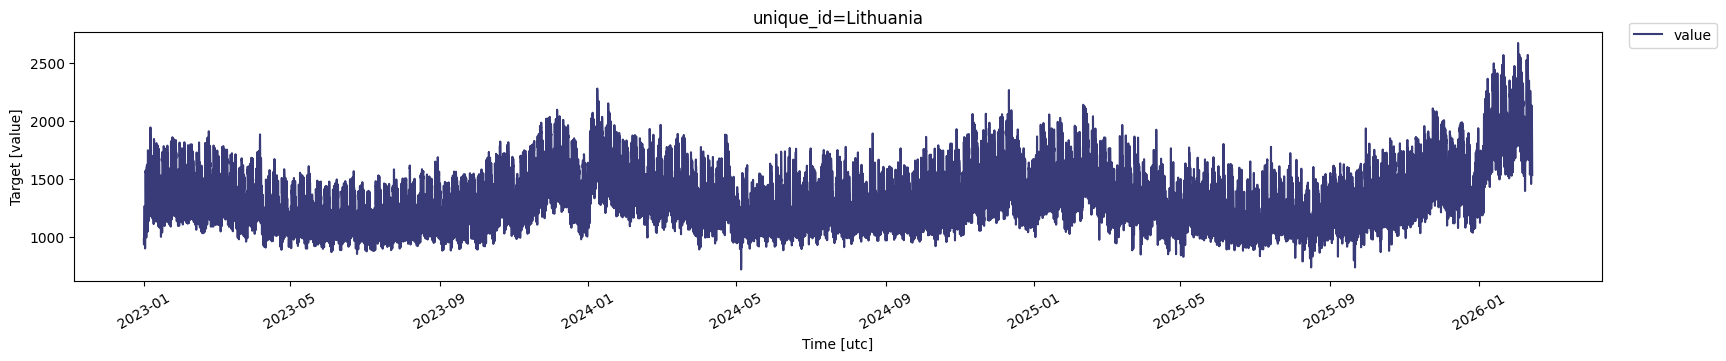

In [71]:
sf.plot(data[['unique_id', 'utc', 'value', 'day_of_week', 'month', 'year', 'temp']], 
       id_col='unique_id', 
       time_col='utc', 
       target_col='value')

In [72]:
sarimax_prediction = pd.DataFrame(data['value'].to_list(), sf.fitted_[0,0].predict_in_sample()['fitted']).reset_index().rename(columns={'index':'ground', 0:'predicted'})

In [73]:
sarimax_prediction['diff'] = sarimax_prediction['ground'] - sarimax_prediction['predicted']

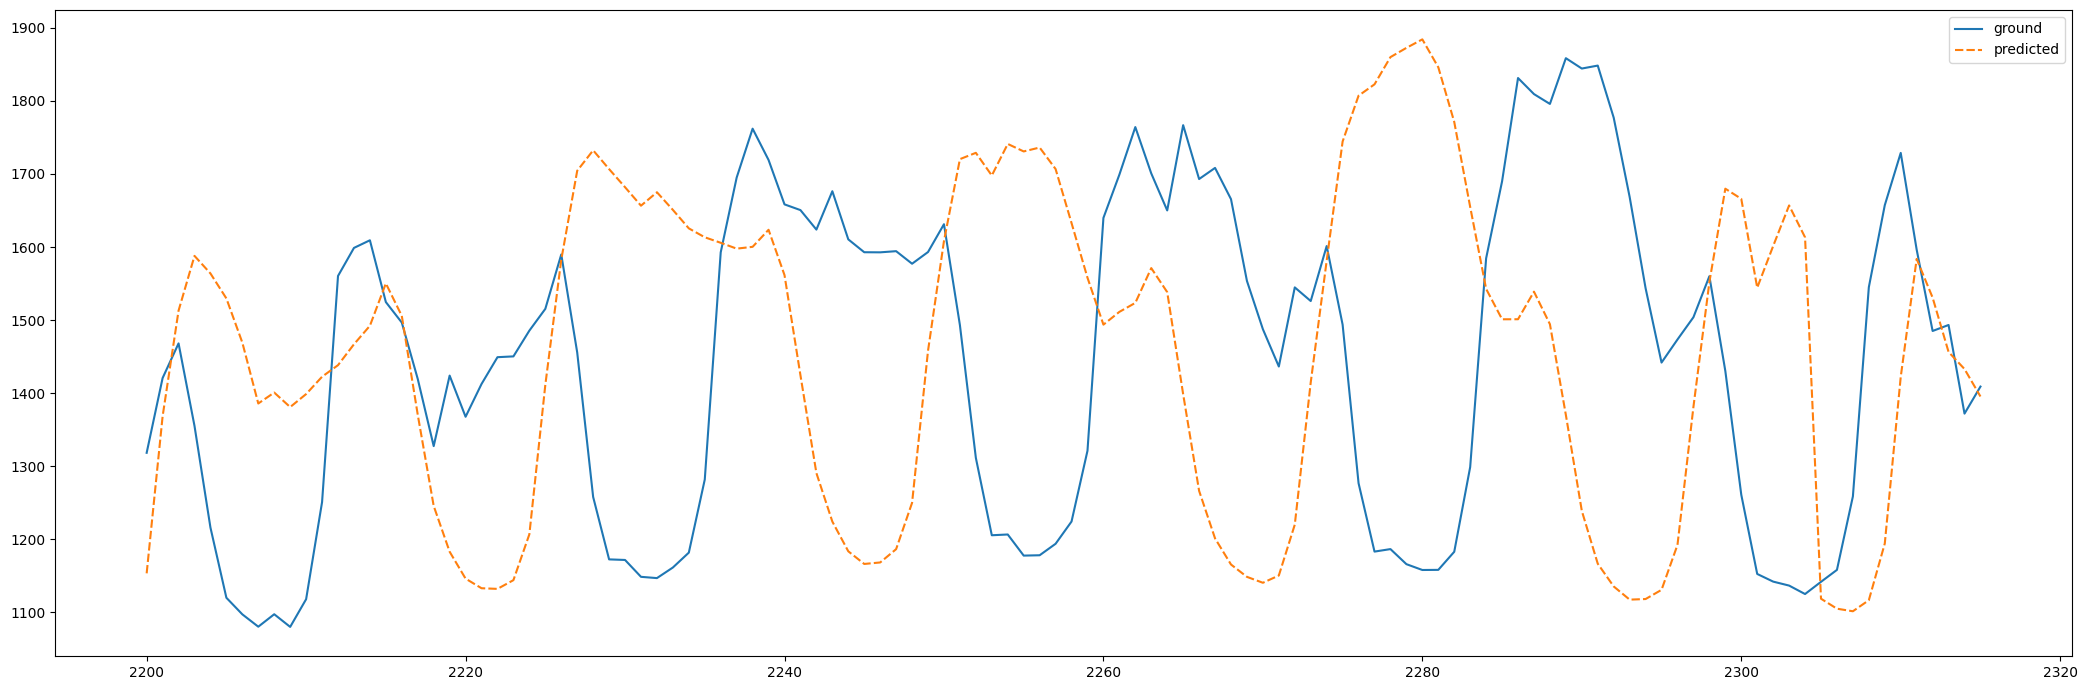

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(sarimax_prediction[['ground', 'predicted']].loc[2200:2315], ax=ax)

plt.tight_layout()
plt.show()

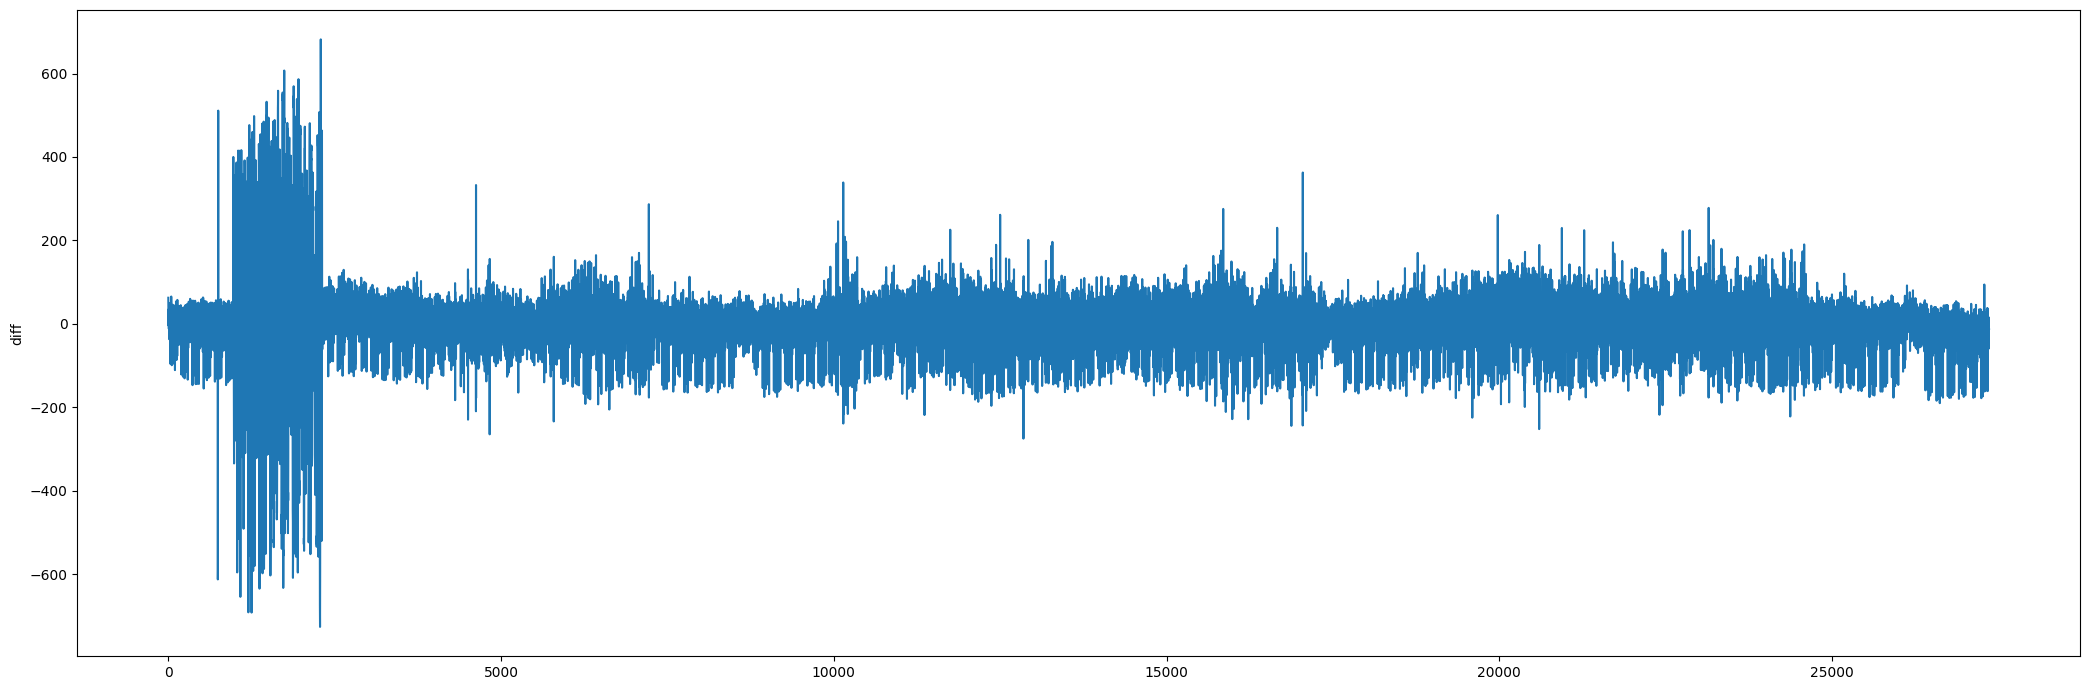

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(sarimax_prediction['diff'], ax=ax)

plt.tight_layout()
plt.show()

In [76]:
sarimax_prediction['diff'].describe()

count    27360.000000
mean        -0.003319
std         82.913651
min       -726.406293
25%        -23.886653
50%          4.980678
75%         26.904423
max        681.918341
Name: diff, dtype: float64

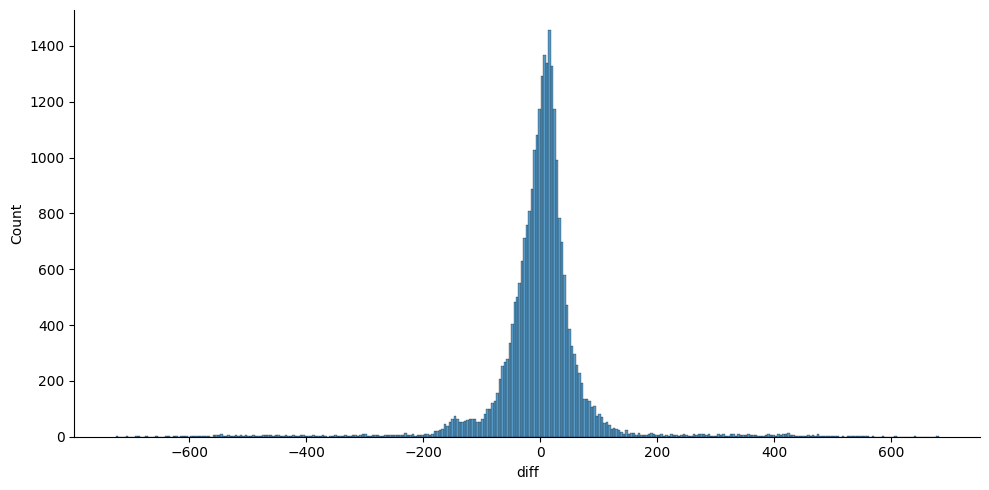

In [77]:
sns.displot(sarimax_prediction['diff'], height=5, aspect=2)

plt.tight_layout()
plt.show()